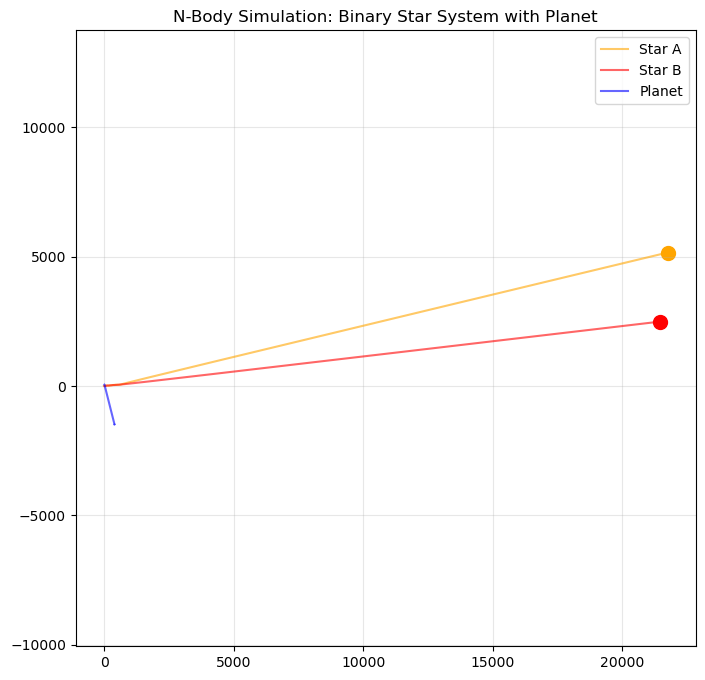

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physics Constants
G = 100  # Gravitational constant (scaled for demo)
dt = 0.01 # Time step
steps = 2000

# 2. Body Properties [Mass, x, y, vx, vy]
# Two heavy "Stars" and one light "Planet"
bodies = [
    {'m': 1000, 'pos': np.array([-20.0, 0.0]), 'vel': np.array([0.0, 10.0]), 'color': 'orange', 'label': 'Star A'},
    {'m': 1000, 'pos': np.array([20.0, 0.0]), 'vel': np.array([0.0, -10.0]), 'color': 'red', 'label': 'Star B'},
    {'m': 1,    'pos': np.array([0.0, 50.0]), 'vel': np.array([15.0, 0.0]), 'color': 'blue', 'label': 'Planet'}
]

# To store paths for drawing
paths = [[] for _ in bodies]

# 3. Simulation Loop
for _ in range(steps):
    for i, b1 in enumerate(bodies):
        total_force = np.array([0.0, 0.0])
        for j, b2 in enumerate(bodies):
            if i == j: continue
            
            # Vector from b1 to b2
            r_vec = b2['pos'] - b1['pos']
            dist = np.linalg.norm(r_vec)
            
            # Force magnitude (clamped to prevent "slingshot" errors)
            force_mag = G * b1['m'] * b2['m'] / max(dist**2, 5)
            total_force += force_mag * (r_vec / dist)
        
        # Acceleration: a = F / m
        accel = total_force / b1['m']
        # Update Velocity and Position
        b1['vel'] += accel * dt
        b1['pos'] += b1['vel'] * dt
        paths[i].append(b1['pos'].copy())

# 4. Visualization
plt.figure(figsize=(8, 8))
for i, b in enumerate(bodies):
    path = np.array(paths[i])
    plt.plot(path[:, 0], path[:, 1], color=b['color'], label=b['label'], alpha=0.6)
    plt.scatter(path[-1, 0], path[-1, 1], color=b['color'], s=b['m']/10)

plt.title("N-Body Simulation: Binary Star System with Planet")
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()